In [1]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from rdkit import Chem
from rdkit.Chem import Descriptors

In [3]:
# Function to plot the density plot
def get_density_plot(data1, data2, name, color1='skyblue', color2='salmon'):
    """
    Plots a comparative density plot for two datasets with customizable colors.

    Parameters:
    data1 (list): First list of numerical values (e.g., sequence lengths)
    data2 (list): Second list of numerical values for comparison
    name (str):   Description of the data (used in title/labels)
    color1 (str): Color for the first dataset (default: 'skyblue')
    color2 (str): Color for the second dataset (default: 'salmon')
    """
    plt.figure(figsize=(6, 4))  # Slightly larger figure for better readability
    
    # Plot density curves with specified colors and transparency
    sns.kdeplot(data1, fill=True, color=color1, alpha=0.4, label='Positive pairs')
    sns.kdeplot(data2, fill=True, color=color2, alpha=0.4, label='Negative pairs')
    
    # Enhanced styling
    plt.title(f'{name} Lengths', fontsize=15)  
    plt.xlabel(f'{name} Length', fontsize=14, labelpad=12)  
    plt.ylabel('Density', fontsize=14, labelpad=12)  
    
    # Customize ticks and grid
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)
    
    # Add legend and adjust layout
    plt.legend(fontsize=12, framealpha=0.9)
    plt.tight_layout()

    # Save high-quality output
    os.makedirs('./figures', exist_ok=True)
    plt.savefig(f'./figures/{name}.png', dpi=600, bbox_inches='tight')
    plt.savefig(f'./figures/{name}.pdf', bbox_inches='tight')
    plt.show()

In [4]:
def plot_sequence_length_distribution(seq_lengths, name1, name2, bin_size=500, figsize=(8, 6), color='skyblue'):
   
    max_len = max(seq_lengths)
    bins = list(range(0, max_len + bin_size, bin_size))

    plt.figure(figsize=figsize)
    counts, bin_edges, patches = plt.hist(seq_lengths, bins=bins, edgecolor='black', color=color)

    total = sum(counts)
    max_counts = max(counts)

    for count, patch in zip(counts, patches):
        height = patch.get_height()
        if height > 0:
            x = patch.get_x() + patch.get_width() / 2
            percent = (count / total) * 100
            plt.text(
                x, height + 1,
                # f'{int(count)} ({percent:.2f}%)',
                f'{int(count)}',
                ha='center', va='bottom', fontsize=10)

    plt.title(f'Distribution of {name1} Lengths', fontsize=15)  
    plt.xlabel(f'{name2}', fontsize=14, labelpad=12)  
    plt.ylabel(f'Number of {name1}', fontsize=14, labelpad=12)  
    plt.xticks(bins, fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(0, max(counts) * 1.1)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()

    plt.savefig(f'./figures/hist_{name1}.png', dpi=600, bbox_inches='tight')
    plt.savefig(f'./figures/hist_{name1}.pdf', bbox_inches='tight')
    plt.show()


In [5]:
def count_atoms(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:  # 处理无效 SMILES
        return 0
    return mol.GetNumAtoms()


def calculate_mw(smiles):

    mol = Chem.MolFromSmiles(smiles)  # 从 SMILES 构建分子对象
    if mol is None:
        raise ValueError("无效的 SMILES 字符串")
    mw = Descriptors.MolWt(mol)  # 计算分子量
    return mw

Index(['DRUG_NAME', 'UNIPROT_ID', 'Label', 'PUBCHEM_CID', 'DRUG_ID', 'SMILES',
       'GENE_SYMBOL', 'SEQUENCE'],
      dtype='object')
12335 12335


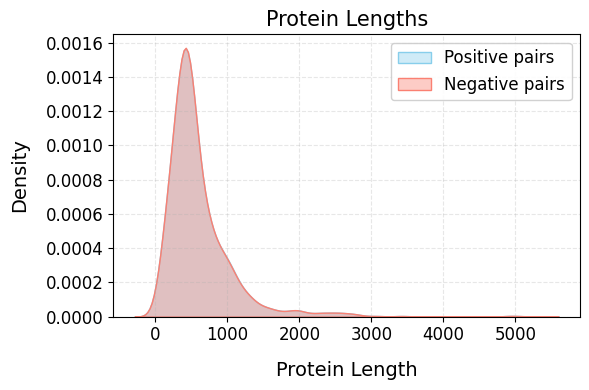

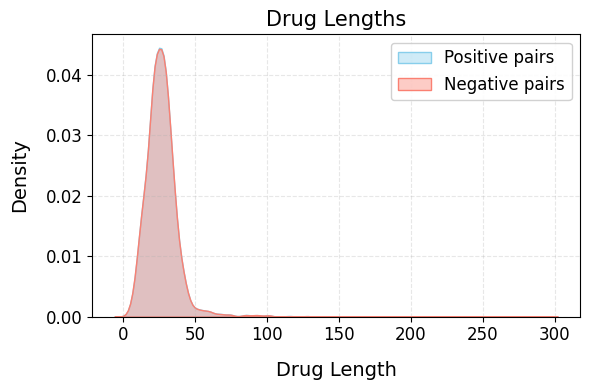

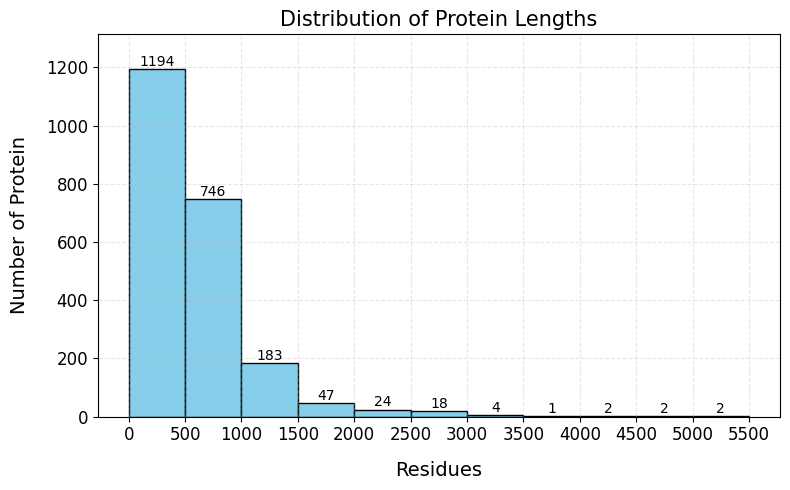

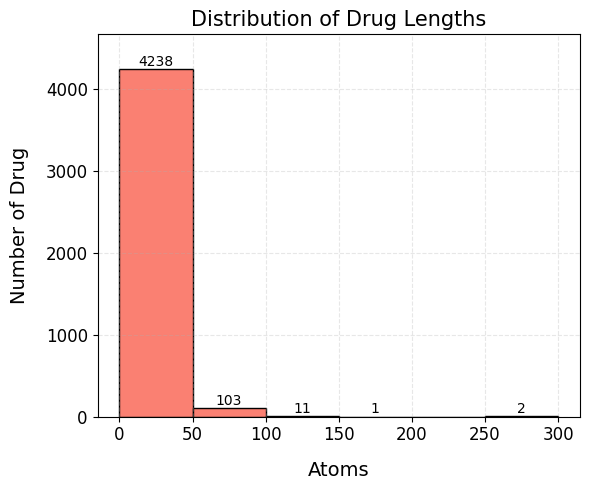

In [6]:
pair_df = pd.read_excel('./process_data/DRH.xlsx')
print(pair_df.columns)

# 2. 去重（可选）：避免重复蛋白
seq_df = pair_df[['UNIPROT_ID', 'SEQUENCE']].drop_duplicates()

# 3. 创建保存目录
save_dir = 'process_data/fasta/'
os.makedirs(save_dir, exist_ok=True)

# 4. 保存每个蛋白为一个单独的 .fasta 文件
for _, row in seq_df.iterrows():
    uniprot_id = row['UNIPROT_ID']
    sequence = row['SEQUENCE']
    
    fasta_path = os.path.join(save_dir, f"{uniprot_id}.fasta")
    with open(fasta_path, 'w') as f:
        f.write(f">{uniprot_id}\n{sequence}\n")

pos_df = pair_df[pair_df['Label']==1]
neg_df = pair_df[pair_df['Label']==0]

print(len(pos_df), len(neg_df))
# 获取所有唯一的正样本蛋白质序列
unique_prots = pos_df['UNIPROT_ID'].unique().tolist()

# 保存到txt文件（每行一个序列）
with open('./process_data/positive_proteins.txt', 'w') as f:
    for prot in unique_prots:
        f.write(prot + '\n')  # 每个序列后加换行符

pos_seqs_len = [len(seq) for seq in pos_df['SEQUENCE'].unique().tolist()]
neg_seqs_len = [len(seq) for seq in neg_df['SEQUENCE'].unique().tolist()]

pos_drugs_atom = [count_atoms(seq) for seq in pos_df['SMILES'].unique().tolist()]
neg_drugs_atom = [count_atoms(seq) for seq in neg_df['SMILES'].unique().tolist()]

get_density_plot(pos_seqs_len, neg_seqs_len, 'Protein')
get_density_plot(pos_drugs_atom, neg_drugs_atom, 'Drug')

plot_sequence_length_distribution(pos_seqs_len, 'Protein', 'Residues', bin_size=500, figsize=(8, 5), color='skyblue')
plot_sequence_length_distribution(pos_drugs_atom, 'Drug', 'Atoms', bin_size=50, figsize=(6, 5), color='salmon')

#### 计算分子之间的相似性

In [ ]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from tqdm import tqdm

def load_molecules_with_ids(smiles_df):
    """加载分子并保留药物ID"""
    molecules = []
    drug_ids = []
    for _, row in smiles_df.iterrows():
        mol = Chem.MolFromSmiles(row['SMILES'])
        if mol is not None:
            molecules.append(mol)
            drug_ids.append(row['DRUG_ID'])
    return molecules, drug_ids

def tanimoto_similarity_matrix_with_ids(molecules, drug_ids):
    """计算相似性矩阵并保留药物ID信息"""
    # 预计算所有指纹
    fps = [AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024) for mol in molecules]
    n = len(fps)
    
    # 初始化矩阵
    similarity_matrix = np.zeros((n, n))

    
    # 计算上三角部分
    for i in tqdm(range(n), desc="计算相似性矩阵"):
        for j in range(i+1, n):
            similarity = DataStructs.TanimotoSimilarity(fps[i], fps[j])
            similarity_matrix[i, j] = similarity

    # 对称填充和对角线
    similarity_matrix = similarity_matrix + similarity_matrix.T
    np.fill_diagonal(similarity_matrix, 1.0)
    
    # 转换为带标签的DataFrame
    labeled_matrix = pd.DataFrame(similarity_matrix, 
                                 index=drug_ids,
                                 columns=drug_ids)
    
    return labeled_matrix


unique_drugs = pair_df[['DRUG_ID', 'SMILES']].drop_duplicates()
molecules, drug_ids = load_molecules_with_ids(unique_drugs)

similarity_matrix_df = tanimoto_similarity_matrix_with_ids(molecules, drug_ids)

# print("\n药物对相似性表格:")
# print(pair_df.head())

# 保存结果
similarity_matrix_df.to_csv('./process_data/drug_similarity_matrix.csv')

[15:46:56] DEPRECATION WARNING: please use MorganGenerator
[15:46:56] DEPRECATION WARNING: please use MorganGenerator
[15:46:56] DEPRECATION WARNING: please use MorganGenerator
[15:46:56] DEPRECATION WARNING: please use MorganGenerator
[15:46:56] DEPRECATION WARNING: please use MorganGenerator
[15:46:56] DEPRECATION WARNING: please use MorganGenerator
[15:46:56] DEPRECATION WARNING: please use MorganGenerator
[15:46:56] DEPRECATION WARNING: please use MorganGenerator
[15:46:56] DEPRECATION WARNING: please use MorganGenerator
[15:46:56] DEPRECATION WARNING: please use MorganGenerator
[15:46:56] DEPRECATION WARNING: please use MorganGenerator
[15:46:56] DEPRECATION WARNING: please use MorganGenerator
[15:46:56] DEPRECATION WARNING: please use MorganGenerator
[15:46:56] DEPRECATION WARNING: please use MorganGenerator
[15:46:56] DEPRECATION WARNING: please use MorganGenerator
[15:46:56] DEPRECATION WARNING: please use MorganGenerator
[15:46:56] DEPRECATION WARNING: please use MorganGenerat


药物对相似性表格:
             DRUG_NAME UNIPROT_ID  Label  PUBCHEM_CID  \
0  (R)-(-)-apomorphine     P08913      1       6005.0   
1              amitraz     P08913      1          NaN   
2        amitriptyline     P08913      1       2160.0   
3            amoxapine     P08913      1       2170.0   
4        apraclonidine     P08913      1       2216.0   

                       DRUG_ID                                  SMILES  \
0  VMWNQDUVQKEIOC-CYBMUJFWSA-N  CN1CCc2cccc-3c2[C@H]1Cc1ccc(O)c(O)c-31   
1  QXAITBQSYVNQDR-ZIOPAAQOSA-N  CN(\C=N\c1ccc(C)cc1C)\C=N\c1ccc(C)cc1C   
2  KRMDCWKBEZIMAB-UHFFFAOYSA-N          CN(C)CCC=C1c2ccccc2CCc2ccccc12   
3  QWGDMFLQWFTERH-UHFFFAOYSA-N      Clc1ccc2Oc3ccccc3N=C(N3CCNCC3)c2c1   
4  IEJXVRYNEISIKR-UHFFFAOYSA-N            Nc1cc(Cl)c(NC2=NCCN2)c(Cl)c1   

           GENE_SYMBOL                                           SEQUENCE  
0  ADRA2A ADRA2R ADRAR  MFRQEQPLAEGSFAPMGSLQPDAGNASWNGTEAPGGGARATPYSLQ...  
1  ADRA2A ADRA2R ADRAR  MFRQEQPLAEGSFAPMGSLQPDAGN

In [ ]:
# import numpy as np
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# from rdkit import Chem
# from rdkit.Chem import AllChem
# from rdkit.Chem import DataStructs

# # 加载或创建分子
# def load_molecules(smiles_list):
#     return [Chem.MolFromSmiles(smiles) for smiles in smiles_list if Chem.MolFromSmiles(smiles) is not None]

# # 计算 Tanimoto 相似性矩阵
# def tanimoto_similarity_matrix(molecules):
#     num_molecules = len(molecules)
#     similarity_matrix = np.zeros((num_molecules, num_molecules))
#     similarity_values = []

#     for i in range(num_molecules):
#         for j in range(num_molecules):
#             if i < j:
#                 fp1 = AllChem.GetMorganFingerprintAsBitVect(molecules[i], 2, nBits=1024)
#                 fp2 = AllChem.GetMorganFingerprintAsBitVect(molecules[j], 2, nBits=1024)

#                 # fp1 = AllChem.GetMACCSKeysFingerprint(molecules[i])
#                 # fp2 = AllChem.GetMACCSKeysFingerprint(molecules[j])
                
#                 similarity = DataStructs.TanimotoSimilarity(fp1, fp2)
#                 similarity_matrix[i, j] = similarity
#                 similarity_values.append(similarity)
#     return similarity_matrix, similarity_values


# ### 计算药物与药物之间的相似性
# smiles_list = pair_df['SMILES'].unique().tolist()
# molecules = load_molecules(smiles_list)
# similarity_matrix, drug_pair_smi = tanimoto_similarity_matrix(molecules)


# #### 计算蛋白与蛋白之间的相似性
# water_df = pd.read_csv('process_data/Water.csv')
# prot_pair_smi = water_df['Similarity'].astype(float) / 100


# ### 绘制密度图
# plt.figure(figsize=(6, 4))  
# sns.kdeplot(drug_pair_smi, fill=True, color='skyblue', label='Protein-protein pair')  
# sns.kdeplot(prot_pair_smi, fill=True, color='salmon', label='Drug-drug pair')  
# plt.title(f'Similarity Distribution', fontsize=15)  
# plt.xlabel(f'Similarity', fontsize=14, labelpad=12)  
# plt.ylabel('Density', fontsize=14, labelpad=12)  
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)
# plt.grid(True, linestyle='--', alpha=0.3) 
# plt.tight_layout()
# plt.legend(fontsize=12)

# plt.savefig('./figures/drug_prot_pair_simi.png', dpi=600, bbox_inches='tight')
# plt.savefig('./figures/drug_prot_pair_simi.pdf', bbox_inches='tight')
# plt.show()  

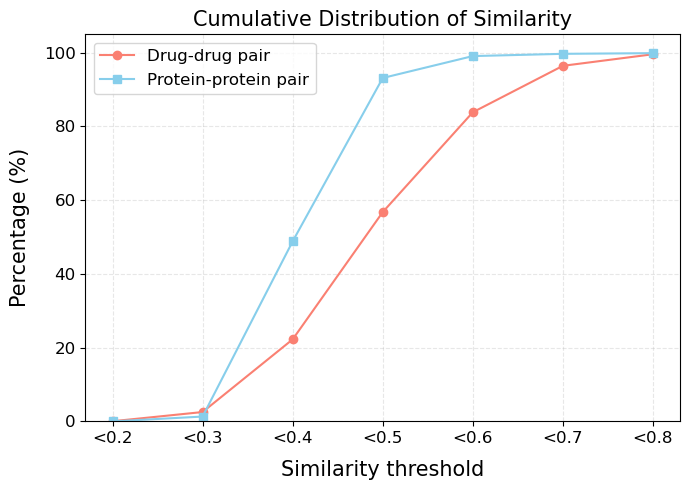

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_similarity_threshold_line(drug_sims, prot_sims, thresholds=np.arange(0.2, 0.9, 0.1)):
    """
    绘制不同相似性阈值下的比例折线图
    """
    drug_percentages = []
    prot_percentages = []

    drug_sims = np.array(drug_sims)
    prot_sims = np.array(prot_sims)

    for t in thresholds:
        drug_ratio = np.mean(drug_sims < t) * 100
        prot_ratio = np.mean(prot_sims < t) * 100
        drug_percentages.append(drug_ratio)
        prot_percentages.append(prot_ratio)

    plt.figure(figsize=(7, 5))
    plt.plot(thresholds, drug_percentages, marker='o', label='Drug-drug pair', color='salmon')
    plt.plot(thresholds, prot_percentages, marker='s', label='Protein-protein pair', color='skyblue')

    plt.xlabel('Similarity threshold', fontsize=14, labelpad=12)
    plt.ylabel('Percentage (%)', fontsize=14, labelpad=12)
    plt.title('Cumulative Distribution of Similarity', fontsize=15)
    plt.xticks(thresholds, [f"<{t:.1f}" for t in thresholds])
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(0, 105)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(fontsize=12)
    plt.tight_layout()

    plt.savefig('./figures/cumulative_distribution_simi.png', dpi=600, bbox_inches='tight')
    plt.savefig('./figures/cumulative_distribution_simi.pdf', bbox_inches='tight')

    plt.show()

plot_similarity_threshold_line(drug_pair_smi, prot_pair_smi)

C:\Users\17608\AppData\Local\Temp\ipykernel_23108\504993657.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=labels, y=percentages, palette='viridis', edgecolor='black')


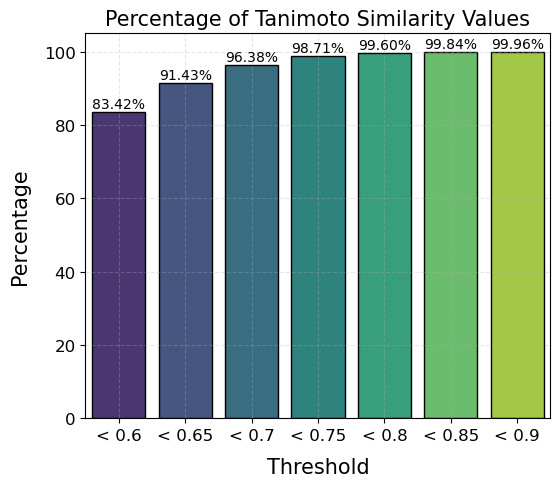

In [ ]:
# # 计算小于0.6, 0.7, 0.8, 0.9的数值占比

# similarity_values = np.array(similarity_values)
# thresholds = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
# percentages = []
# labels = []
# for threshold in thresholds:
#     count_below_threshold = np.sum(similarity_values < threshold)
#     total_count = len(similarity_values)
#     percentage = (count_below_threshold / total_count) * 100
#     percentages.append(percentage)
#     labels.append(f"< {threshold}")

# # 绘制柱状图
# plt.figure(figsize=(6, 5))
# bars = sns.barplot(x=labels, y=percentages, palette='viridis', edgecolor='black')

# for i, percentage in enumerate(percentages):
#     bars.text(i, percentage + 0.25, f"{percentage:.2f}%", ha='center', va='bottom', fontsize=10)

# plt.title('Percentage of Tanimoto Similarity Values', fontsize=15)
# plt.xlabel('Threshold', fontsize=15, labelpad=10)
# plt.ylabel('Percentage', fontsize=15, labelpad=10)
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)
# plt.grid(True, linestyle='--', alpha=0.3) 
# plt.savefig('./figures/drug_simi_percentage.png', dpi=600, bbox_inches='tight')
# plt.savefig('./figures/drug_simi_percentage.pdf', bbox_inches='tight')
# plt.show()

#### 绘制Panther分析的柱状图

In [ ]:
panther_df = pd.read_csv('process_data/pantherChart.txt', header=None, sep='\t')
panther_df.columns = ['ID', 'Category', 'Number', 'Ratio', 'Percent']
panther_df["Ratio"] = panther_df["Ratio"].str.replace('%', '').astype(float)
panther_df[['Description', 'Class']] = panther_df['Category'].str.extract(r'^(.*?)\s+\((PC\d+|UNCLASSIFIED)\)$')

sorted_panther_df = panther_df.sort_values(by="Ratio", ascending=False).reset_index(drop=True)
sorted_panther_df = sorted_panther_df.head(10)
sorted_panther_df

,ID,Category,Number,Ratio,Percent,Description,Class
0,14,metabolite interconversion enzyme (PC00262),618,27.9,27.9%,metabolite interconversion enzyme,PC00262
1,15,protein modifying enzyme (PC00260),341,15.4,15.4%,protein modifying enzyme,PC00260
2,3,transporter (PC00227),334,15.1,15.1%,transporter,PC00227
3,22,transmembrane signal receptor (PC00197),265,12.0,12.0%,transmembrane signal receptor,PC00197
4,23,No PANTHER category is assigned (UNCLASSIFIED),177,8.0,8.0%,No PANTHER category is assigned,UNCLASSIFIED
5,11,gene-specific transcriptional regulator (PC00264),81,3.7,3.7%,gene-specific transcriptional regulator,PC00264
6,8,protein-binding activity modulator (PC00095),52,2.3,2.3%,protein-binding activity modulator,PC00095
7,2,cytoskeletal protein (PC00085),42,1.9,1.9%,cytoskeletal protein,PC00085
8,13,translational protein (PC00263),41,1.9,1.9%,translational protein,PC00263
9,16,"chromatin/chromatin-binding, or -regulatory pr...",34,1.5,1.5%,"chromatin/chromatin-binding, or -regulatory pr...",PC00077


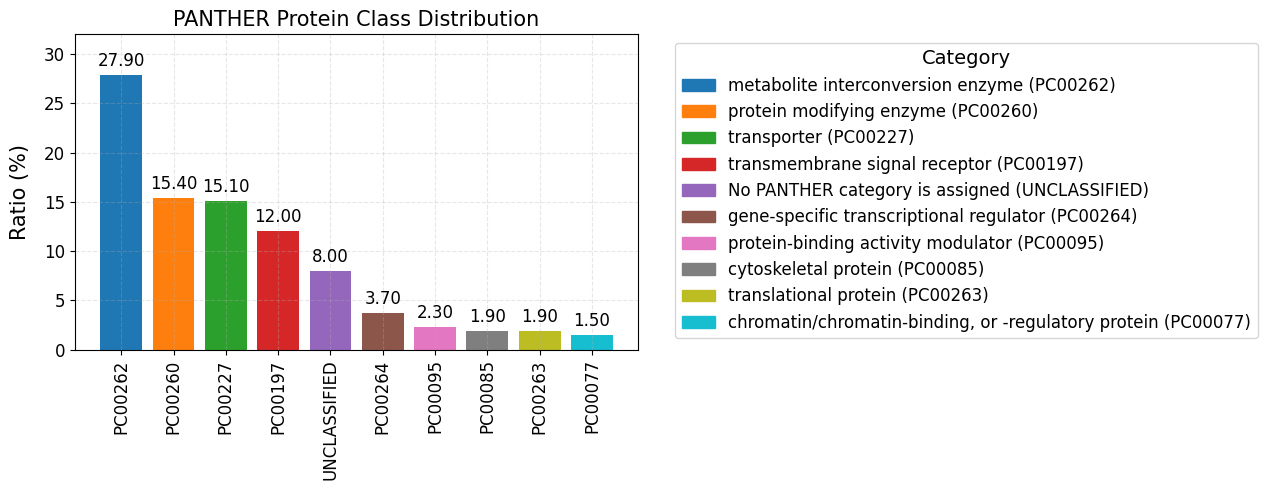

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# 设置颜色（根据类别数自动取色）
num_categories = len(sorted_panther_df)
colors = cm.tab10(np.linspace(0, 1, num_categories))

plt.figure(figsize=(13, 5))
bars = plt.bar(sorted_panther_df["Class"], sorted_panther_df["Ratio"], color=colors)

# 添加文字标签
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval+0.5, f"{yval:.2f}", 
             ha='center', va='bottom', fontsize=12)

plt.ylim(0, 32)
plt.xticks(fontsize=12, rotation=90) #
plt.yticks(fontsize=12)
plt.ylabel("Ratio (%)", fontsize=14, labelpad=12)
plt.title("PANTHER Protein Class Distribution", fontsize=15)
plt.grid(True, linestyle='--', alpha=0.3)

# 添加图例
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[i]) for i in range(num_categories)]
labels = sorted_panther_df["Category"].tolist()
plt.legend(handles, labels, title="Category", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=14)

plt.tight_layout()
plt.savefig('./figures/protein_class_distribution.png', dpi=600, bbox_inches='tight')
plt.savefig('./figures/protein_class_distribution.pdf', bbox_inches='tight')
plt.show()


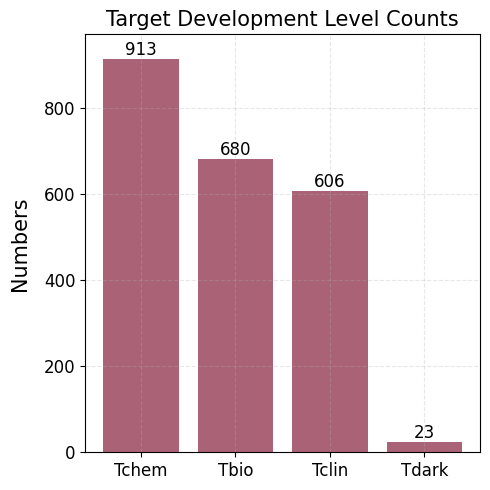

In [ ]:
pharos_df = pd.read_csv(r'F:\SUSTech-Code\pharos_data_2025_06_12\query results.csv')
select_pharos_df = pharos_df[pharos_df['UniProt'].isin(unique_prots)]

# 1. 统计每个类型的数量
tdl_counts = select_pharos_df['Target Development Level'].value_counts()

# 2. 绘制柱状图
plt.figure(figsize=(5, 5))
bars = plt.bar(tdl_counts.index, tdl_counts.values, color='#AA6376')

# 添加文本标签
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=12)

# 设置标题和标签
plt.title("Target Development Level Counts", fontsize=15)
# plt.xlabel("Target Development Level", fontsize=15, labelpad=10)
plt.ylabel("Numbers", fontsize=14, labelpad=12)

plt.xticks(fontsize=12) 
plt.yticks(fontsize=12)
plt.ylim(0, 970)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.savefig('./figures/target_development_level.png', dpi=600, bbox_inches='tight')
plt.savefig('./figures/target_development_level.pdf', bbox_inches='tight')
plt.show()

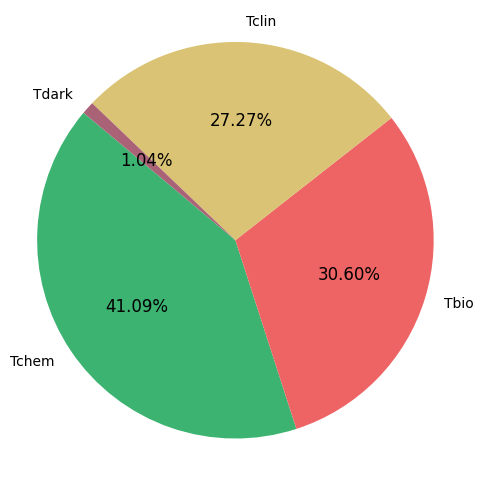

In [ ]:
tdl_counts = select_pharos_df['Target Development Level'].value_counts()
colors = ['#3CB371', '#EE6363', '#DAC374', '#AA6376']
# 画饼图
plt.figure(figsize=(5, 5))

wedges, texts, autotexts = plt.pie(
    tdl_counts.values,
    labels=tdl_counts.index,
    autopct='%1.2f%%',
    startangle=140,
    colors=colors
)

# 让百分比文字更清晰一些
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(12)

plt.axis('equal')  # 保证是圆形
plt.tight_layout()

plt.savefig('./figures/pie_chart.png', dpi=600, bbox_inches='tight')
plt.savefig('./figures/pie_chart.pdf', bbox_inches='tight')
plt.show()

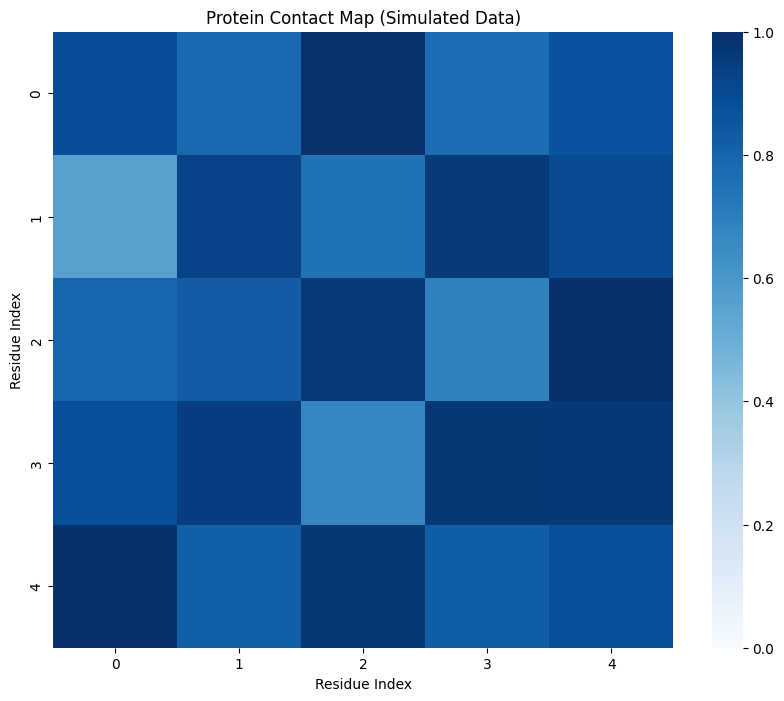

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置随机种子以便结果可复现
# np.random.seed(42)

# 生成假的contact map数据
protein_length = 5  # 假设蛋白质有50个氨基酸

# 创建一个空的contact map矩阵
contact_map = np.zeros((protein_length, protein_length))

# 填充一些随机接触点
for i in range(protein_length):
    for j in range(i+1, protein_length):
        # 邻近残基更可能有接触
        if abs(i - j) < 5:
            contact_map[i, j] = np.random.uniform(0.7, 1.0)
        # 随机长程接触
        elif np.random.random() < 0.05:
            contact_map[i, j] = np.random.uniform(0.3, 0.8)

# 使矩阵对称（因为contact map是对称的）
contact_map = contact_map + contact_map.T

# 对角线设置为1（每个残基与自身接触）
np.fill_diagonal(contact_map, 1)

# 添加一些噪声使数据更真实
noise = np.random.normal(0, 0.1, (protein_length, protein_length))
contact_map = np.clip(contact_map + noise, 0, 1)

# 绘制热图
plt.figure(figsize=(10, 8))
sns.heatmap(contact_map, cmap='Blues', vmin=0, vmax=1)
plt.title('Protein Contact Map (Simulated Data)')
plt.xlabel('Residue Index')
plt.ylabel('Residue Index')
plt.show()